# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Sissi Wang]

**Date:** [09/10/2026]

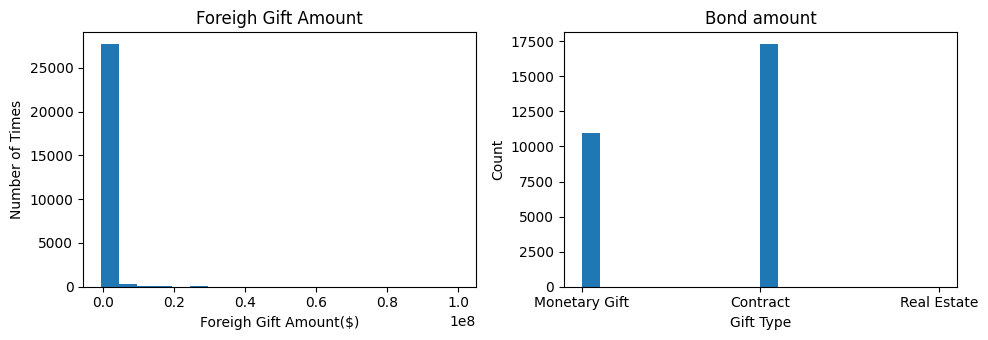

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


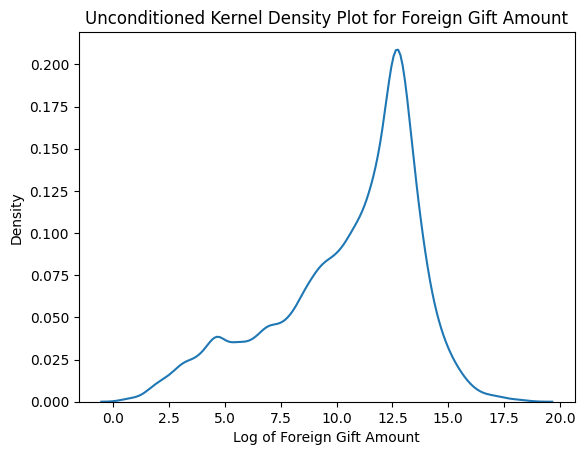

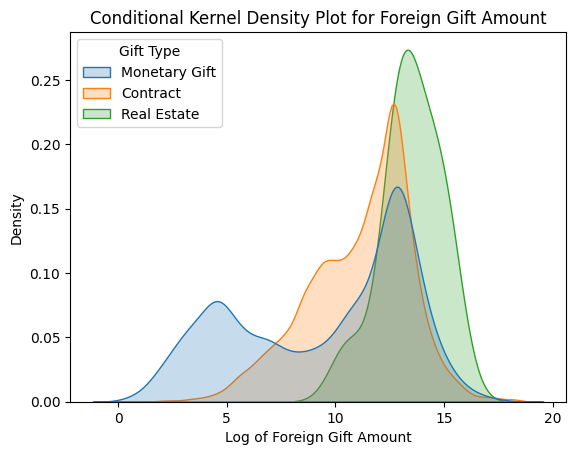

Top 15 countries in terms of the number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Top 15 countries in terms of the amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUST

In [ ]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# 1. Load the `./data/ForeignGifts_edu.csv` dataset.

df = pd.read_csv('./data/ForeignGifts_edu.csv')

# 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.

# Create a histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[0])
axes[0].set(title="Foreigh Gift Amount", xlabel="Foreigh Gift Amount($)", ylabel="Number of Times")

# Findings:
# The gift amount is heavily right skewed due to a few extremely large outliars. You can tell this from the long tail to the right 
# or from the fact that the mean is greater than the median.


# 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

# Create histogram
df["Gift Type"].hist(bins=20, grid=False, ax=axes[1])
axes[1].set(title="Gift amount", xlabel="Gift Type", ylabel="Count")
plt.tight_layout()
plt.show()
# Show proportion of the gift types
print(df["Gift Type"].value_counts(normalize=True))
# Based on the table, 61.2% of gifts are Contract, 38.75% of  gifts are monetary gifts, and 0.03% of gifts are Real Estate.


# 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` 
# conditional on gift type. Do you notice any patterns?

# Because there is negative values in the Foreign Gift Amount, I will first filter out those rows before applying the log transformation
df_pos = df[df['Foreign Gift Amount'] > 0]

# Log transform Foreign Gift Amount
df_pos["log_gift_amount"] = np.log1p(df_pos["Foreign Gift Amount"])

# Create unconditioned and conditioned kernel density plots
sns.kdeplot(df_pos["log_gift_amount"])
plt.title('Unconditioned Kernel Density Plot for Foreign Gift Amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()
sns.kdeplot(data=df_pos, x="log_gift_amount", hue="Gift Type", fill=True, common_norm=False)
plt.title('Conditional Kernel Density Plot for Foreign Gift Amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()

# Patterns:
# Log transformation normalizes the heavily skewed distribution, showing the underlying patterns more clearly 
# Before log transformation, the distribution was heavily right skewed by a few extremely large outliers
# After log transformation, underlying patterns starting to show and based on the unconditioned KDE, it is slightly left skewed
# This shows that the majority of the gifts are small, most of them are around $268,000,with a few large gifts skewing the distribution to the right.
# In the conditional KDE, all three types of gifts all peak around the same value, but monetary gifts have a second peak around $150
# representing small donations from foreigh countries. The conditional KDE also shows that monetary gifts have a wider distribution than
# the other two types of gifts, showing that they are more variable in size.

# 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
# Top 15 by number of gifts
number_of_gifts = df.groupby("Country of Giftor").size()
top_15_countries_number = number_of_gifts.sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the number of gifts:")
print(top_15_countries_number)

# Top 15 by amount given
amount_given = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
top_15_countries_amount = amount_given.sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the amount given:")
print(top_15_countries_amount)

# 6. Which giftors provide the most money, in total?
giftors = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
top_giftor = giftors.sort_values(ascending=False).head(1)
print("Giftor that provides the most money in total:")
print(top_giftor)


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [a625a39c48a2ab042bb6e2a61488458b16c0bca6]
- **AI tool and model used:** [Gemini 3.6 Flash]

### *Prompts used

1. [[Datasheet and notebook attached]The assignment directions is in the notebook, I have completed the steps for phase 1, please give bullet point suggestions to make my code better or better completing the assignment]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Fix Pandas SettingWithCopyWarning (Q2.4): Creating df_pos["log_gift_amount"] directly on a slice of df triggers pandas warnings. Use .copy() explicitly when subsetting
2. Avoid Double Log Transformation (Q2.4): You used np.log1p() after explicitly filtering for Foreign Gift Amount > 0. Standard natural log np.log() is preferred once zero/negative values are filtered, as log1p(x) = log(1 + x) slightly shifts values (which matters when dealing with currency units).
3. Give an example for part 4 of Q1.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| Modifications to this new subset could have accidently modify the original to. Creating a copy is the safest way if I want to 100 percent make sure that the dataframes are independent of each other. |
| 2 | Accept | Because I filtered my finance amount to be greater than 0, there is no need to use log1p to shift the data to avoid 0s. |
| 3 | Accept |  |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

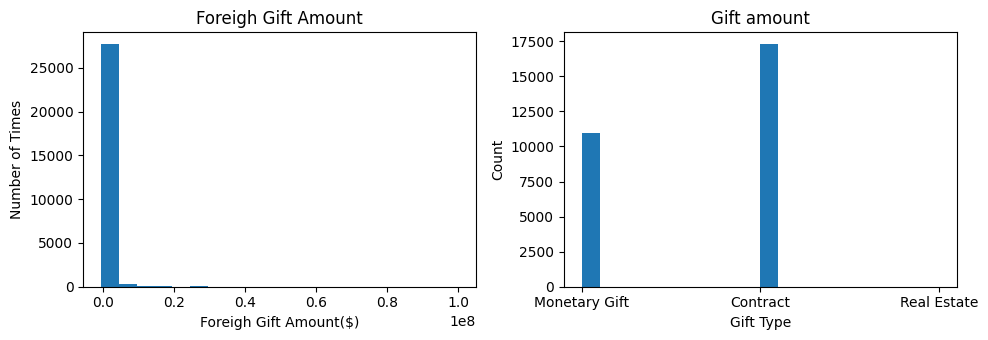

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


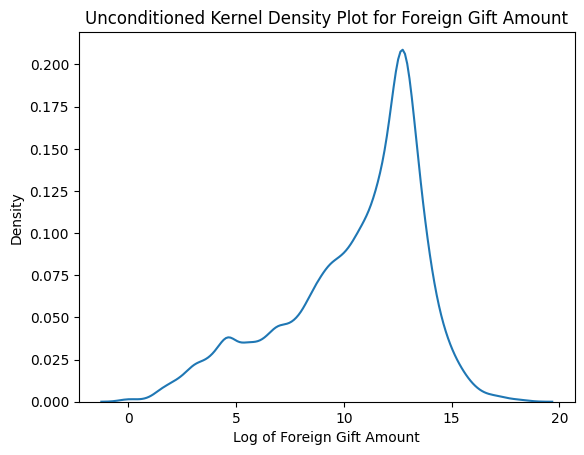

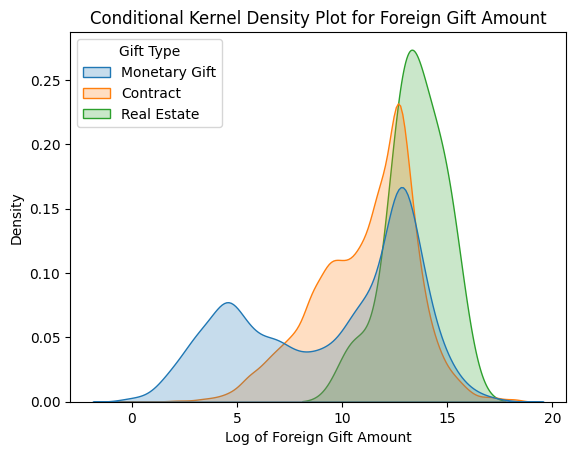

Top 15 countries in terms of the number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Top 15 countries in terms of the amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUST

In [32]:
# Your Phase 2 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# 1. Load the `./data/ForeignGifts_edu.csv` dataset.

df = pd.read_csv('./data/ForeignGifts_edu.csv')

# 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.

# Create a histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df["Foreign Gift Amount"].hist(bins=20, grid=False, ax=axes[0])
axes[0].set(title="Foreigh Gift Amount", xlabel="Foreigh Gift Amount($)", ylabel="Number of Times")

# Findings:
# The gift amount is heavily right skewed due to a few extremely large outliars. You can tell this from the long tail to the right 
# or from the fact that the mean is greater than the median.


# 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?

# Create histogram
df["Gift Type"].hist(bins=20, grid=False, ax=axes[1])
axes[1].set(title="Gift amount", xlabel="Gift Type", ylabel="Count")
plt.tight_layout()
plt.show()
# Show proportion of the gift types
print(df["Gift Type"].value_counts(normalize=True))
# Based on the table, 61.2% of gifts are Contract, 38.75% of  gifts are monetary gifts, and 0.03% of gifts are Real Estate.


# 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` 
# conditional on gift type. Do you notice any patterns?

# Because there is negative values in the Foreign Gift Amount, I will first filter out those rows before applying the log transformation
df_pos = df[df['Foreign Gift Amount'] > 0].copy()

# Log transform Foreign Gift Amount
df_pos['log_gift_amount'] = np.log(df_pos['Foreign Gift Amount'])

# Create unconditioned and conditioned kernel density plots
sns.kdeplot(df_pos["log_gift_amount"])
plt.title('Unconditioned Kernel Density Plot for Foreign Gift Amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()
sns.kdeplot(data=df_pos, x="log_gift_amount", hue="Gift Type", fill=True, common_norm=False)
plt.title('Conditional Kernel Density Plot for Foreign Gift Amount')
plt.xlabel('Log of Foreign Gift Amount')
plt.show()

# Patterns:
# Log transformation normalizes the heavily skewed distribution, showing the underlying patterns more clearly 
# Before log transformation, the distribution was heavily right skewed by a few extremely large outliers
# After log transformation, underlying patterns starting to show and based on the unconditioned KDE, it is slightly left skewed
# This shows that the majority of the gifts are small, most of them are around $268,000,with a few large gifts skewing the distribution to the right.
# In the conditional KDE, all three types of gifts all peak around the same value, but monetary gifts have a second peak around $150
# representing small donations from foreigh countries. The conditional KDE also shows that monetary gifts have a wider distribution than
# the other two types of gifts, showing that they are more variable in size.

# 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
# Top 15 by number of gifts
number_of_gifts = df.groupby("Country of Giftor").size()
top_15_countries_number = number_of_gifts.sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the number of gifts:")
print(top_15_countries_number)

# Top 15 by amount given
amount_given = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
top_15_countries_amount = amount_given.sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the amount given:")
print(top_15_countries_amount)

# 6. Which giftors provide the most money, in total?
giftors = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
top_giftor = giftors.sort_values(ascending=False).head(1)
print("Giftor that provides the most money in total:")
print(top_giftor)


### *Reflection on AI assistance
In your own words without generative AI.


[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The use of artificial intelligence pointed out minor flaws in my code and overall made it more efficient with explanations. In phase 1, I was able to successfully solve the problems stated, but improvements could have been made. These changes are reflected in my phase 2 of the assignment. When it came to evaluating the changes that AI suggested, I accepted the tasks because it directly made my code better by making it efficient. There were minor changes that I could have rejected for the same result of the question being solved, but learning how to efficiently code is quite beneficial especially in fields like data science to save more time and energy. For this reason, I accepted all of the changes that AI suggested. The AI was not necessarily limited in this case as I had the problems mostly solved, so it provided alternate quicker solutions. To ensure that the AI changes were verified, I printed out the results and made sure that they aligned with the expected results. I would say that my use of AI here was more for the purpose of verifying and checking my solutions because the data I received lined up with the questions and their expected result. Additionally, I think that since I better understood this A2 assignment compared to the A1, I was able to rely on AI less for phase 2. This assignment was easier to understand after already doing A1. The use of artificial attendance was beneficial for my phase 2 as it allowed my code to be more efficient, and I learned how to do this from the start so that I may be able to apply it to the next assignment. 